# Módulo 3: Preprocesamiento

## Leakage & feature engineering

#### Objetivo 

* Definiremos qué es la ingeniería de variables, su utilidad y aplicación en la vida diaria de un data scientist.
* Aplicaremos a una base sintética un proceso de feature engineering y probaremos la utilidad del concepto.

#### Actividad 1
* Abordar y comprender tres tipos básicos de _leakage_:
    * Target
    * Time
    * User
        * Tomar el dataset `user_leakage.csv` de Canvas. 
        
* Abordar y comprender _feature engineering_ para instancias temporalmente dependientes. 
    * Tomar el dataset `feature_eng_time_dependant.csv` de Canvas.
    * Generar nuevas variables en dos grupos:
        * Grupos de variables de cambio.
        * Grupos de rezagos. 
    * Generar un mapa de correlaciones para observar la influencia de las nuevas variables. 
* Abordar y comprender _feature engineering_ para instancias temporalmente independientes pero con repetición de usuarios. 
    * Tomar el dataset `AB_NYC_2019_class.csv` de Canvas. 
    * Generar nuevas variables en dos grupos:
        * Variables de usuario.
        * Variables a partir de las existentes. 
    * Generar bivariados para la comparación de éxito de las variables. 


#### Actividad 2

* Tarea I: Stocks. 
    * Genera al menos 3 propuestas de variables que no hayan sido generadas en clase.
        * Generar solo más rezagos (por ejemplo 15 en lugar de 7) no será tomado en cuenta. 
    * Calcula las correlaciones de tus variables con la variable de respuesta.
    * Responde: ¿Tus variables tienen una correlación alta o baja con la respuesta? ¿Por qué crees que pase eso? 
* Tarea II: Airbnb.
    * Proponer 5 variables nuevas de las cuales: 
        * Dos tienen que tener relación entre usuarios (como el ejemplo de clase). Recuerda que para generarlas a todo el frame puedes usar `shift` y `expanding`. 
        * Cuidar en las 5 temas de feature leakage, sobre todo en el punto anterior.
    * Generar gráficas de bivariados de tus nuevas variables y hacer análisis al respecto. 
    * Responde: ¿Tus variables muestran una relación adecuada en los bivariados? ¿Por qué crees que pase eso? 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from math import radians, cos, sin, asin, sqrt
from sklearn.metrics import mean_absolute_error, median_absolute_error, roc_auc_score
import re
import time
import os
import sys
import warnings
import pickle

warnings.filterwarnings("ignore")

%matplotlib inline
plt.style.use('ggplot')

seed = 28
path = '.'

###  Leakage 

Este fenómeno ocurre cuando nuestro set de entrenamiento contiene información "futura" (generalmente de manera no intencional) o que tiene información en distinta medida de nuestra variable de respuesta. 

A manera de regla empírica podemos asumir que si el modelo es demasiado bueno para ser cierto, si el modelo está mostrando un performance productivo mucho menor que el de desarrollo o si hay _overfitting_, podría deberse a este fenómeno. 

Algunos de los leakages más comunes:
* Target. 
* User.
* Time.



#### Target leakage 

Este tipo de _leakage_ particular es uno muy común y muy fácil de detectar. 

_¿En qué consiste?_

En incluir la variable de respuesta o una transformación de la misma en el conjunto de entrenamiento. 

In [2]:

import pandas as pd
precios = [100, 200, 500, 300, 150]
metros_cuadrados = [10, 30, 60, 35, 15]

df = pd.DataFrame()
df['precios'] = precios
df['m2'] = metros_cuadrados
df



,precios,m2
0,100,10
1,200,30
2,500,60
3,300,35
4,150,15


Suponga que en el ejemplo anterior usted tiene la variable independiente `m2` y estimará la variable dependiente `precios`.



In [2]:
# Modelo


In [3]:
# Predicciones


Haremos una pausa para introducir otra métrica de evaluación de modelos de regresión, el `MAE`. 

$$\text{MAE} = \frac{1}{n} \sum_{i=0}^n \vert y_i - \hat{y_i} \vert$$

Mediremos el `MAE`:

Casi cero. 

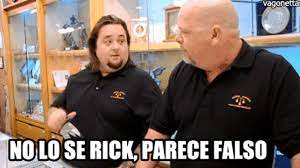

Generemos ahora un modelo sin `precios` como parte de los predictores. 

In [4]:


# Reshape porque si no scikit llora. 


Nuevamente el `MAE`. 

Observemos coeficientes de ambos modelos

Lo que hicimos en realidad con el primer modelo fue algo así: 






$$\text{precio} =  \beta_0 \times \text{precio} + \beta_1 \times m^2$$

$$\text{precio} =  \text{precio} - 1x10^{-15} \times m^2$$



Mientras que el segundo modelo fue algo así: 

$$\text{precio} = 7.90 \times m^2$$

Claramente el modelo con _leakage_ tiene una ventaja: Ya conoce la respuesta. Literalmente está haciendo trampa. 

#### User leakage 

El _leakage_ de usuarios se da cuando son pocas las características que se tienen para identificación de usuarios y se usa a un mismo usuario (o a varios) en un _set_ de evaluación y otro de entrenamiento. 

Suponga tiene el siguiente set:

In [5]:
df = pd.read_csv('user_leakage.csv')
df.head()

Vamos a tomar los primeros 8 renglones (80%) para generar un modelo. Después vamos a evaluar su performance usando `MAE` en ese mismo set y en el set que quedó fuera. 

Separemos sets:

Generemos un modelo: 

Midamos el error en `train` y en `test`. 

Primero en `train`: 

Ahora en `test`: 

El error es considerablemente mayor en `test` (~25% mayor) que en `train`. 

Esto es de esperarse pues el modelo se entrenó con `train`. 

Hagamos el ejercicio de nuevo pero con todos nuestros datos. 

El error se ubica entre el del `train` y el del `test`. 

Esto se debe a que los errores mutuamente se netean y le estamos dando una ventaja injusta en esta evaluación:

* Lo estamos evaluando con usuarios que ya conoció y de los que ya aprendió. 

#### Time leakage

Uno de los más comunes entre la comunidad de _data science_, se trata de la incorporación de información futura sin tener en cuenta el cambio en el tiempo. 

Tomemos en cuenta el siguiente flujo de predicción. 

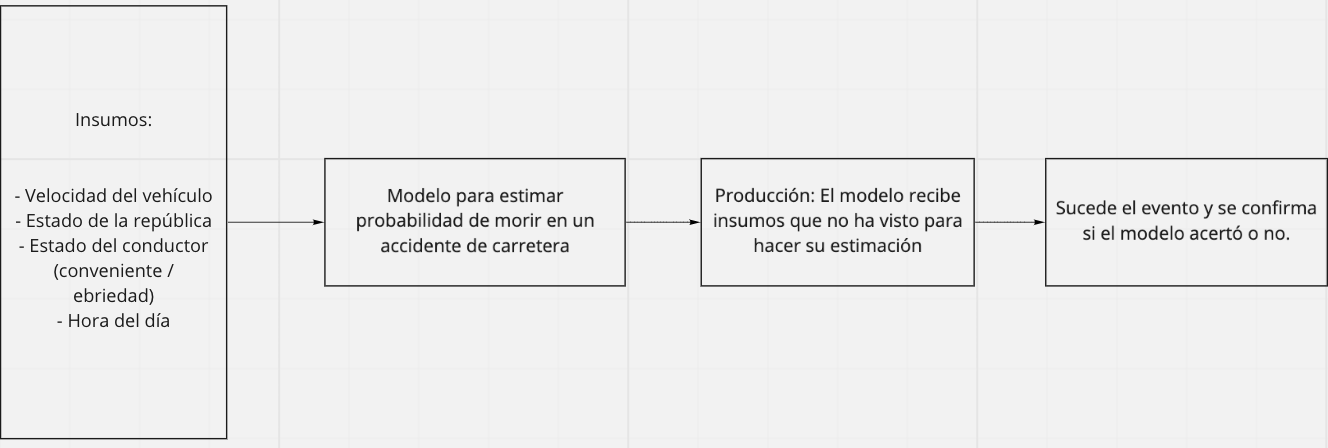

Al incorporar en el modelo la variable "tiempo de duración de la autopsia" incurrimos en _time leakage_ o _future leakage_ :

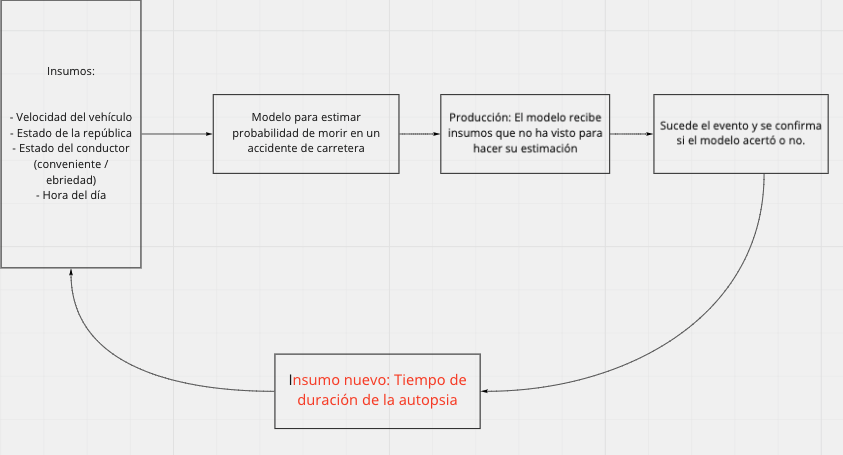

Generamos una referencia circular, el modelo tendrá un performance excelente pero irreal. 



###  Feature engineering 

El proceso de ingeniería de variables consiste en generar nuevas variables a partir de las existentes y/o nuevas fuentes de información. 


Para poder generar nuevas variables es **de vital importancia** tener en cuenta el _leakage_. 


Supongamos el caso de _Netflix_ (recomendación de series/películas). Algunas preguntas guía que nos podemos hacer son: 

* ¿Qué me preguntaría a mí mismo para darle pistas a Netflix de lo que me gusta ver?
* ¿Qué influye en mi comportamiento que puede determinar mi siguiente paso?
* ¿Cómo puedo generar información ortogonal  en mi _dataset_ a partir de lo que ya tengo?  


#### Feature engineering w/stocks: Netflix case

Empezaremos con la estimación de precios reportados en Y!Finance. Para la descarga de información se utilizó: https://pypi.org/project/yfinance/.




In [6]:
df = pd.read_csv('feature_eng_time_dependant.csv', index_col=0)
df

Si no tenemos otro tipo de información más que el precio, ¿qué podemos utilizar? 

* ¿Cómo inició el precio ese día? 
* ¿Cómo cerró el precio ese día? 
* ¿Cuál fue el más alto del día? 
* ¿Cuál fue el más bajo del día? 

En lugar de eliminar todas esas columnas, las aprovecharemos a manera de features independientes (aunque temporalmente dependan unos de otros). 


##### ¿Qué más? 

Esos datos ya son provistos por la API, ¿qué tal si intentamos replicar ese comportamiento a lo largo del tiempo? 


##### Acomodando precios

No podemos considerar el precio del día de hoy para estimar el precio del día de hoy. 


**Disclaimer: Se asume que el modelo correrá en las mañanas tal que se puede saber el precio de cierre del día anterior.**

In [7]:
df.head()

In [8]:
# Lagging our frame
response = 'close_today'



# Adding response


Info del 2 de enero se pasa a ser la predictora del día 3: 
<img src="leakage_from_yesterday.png">

La respuesta (el precio de cierre) del día 3 se mantiene y la info de ayer (2 de enero) se elimina. 

<img src="leakage_from_yesterday2.png">

Con esto tenemos que:
* `close_tday` es el precio de cierre del día en cuestión (el del índice). 
* `close_yday` es el precio de cirre del día anterior. En el renglón del 3 de enero, este valor será el del 2 de enero.
* Todos los demás datos corresponden a los datos del día anterior. 

**No olvides el leakage.**

##### Delta de precios

$$ \Delta y_t = y_{t-1} - y_{\text{open}, t-1}  $$


##### Cambio (delta) relativo de precios

$$ \Delta_{rel} y_t = \frac{y_{t-1}}{y_{\text{open}, t-1}} - 1   $$


In [9]:
# Delta



# Deltarel



Podemos hacer lo mismo con high y low, por lo que para evitar la fatiga de codear generaremos una función. 

Comprobando que sirva. 

#### Uso del histórico
En clases anteriores ya habíamos utilizado los famosos rezagos, generemos al menos un rezago de una semana. 

In [10]:
lags = 7 


#### Mapa de correlaciones

La correlación se define como: 

$$ \rho = \frac{\text{cov}(X, Y)}{\sigma_x\sigma_y}$$

Observamos que esta serie en particular tiene una alta relación los _lags_, sin embargo observamos que dos de las variables nuevas (deltas del precio máximo del día anterior y del precio bajo del día anterior) tienen correlaciones interesantes con la variable target. 

#### Feature engineering w/independent instances: Airbnb case

In [11]:
file_name = 'AB_NYC_2019_class.csv'
df = pd.read_csv(os.path.join(path, file_name))
df.head()

##### Uso de datos geográficos

Un punto de referencia clásico en NYC es Times Square. Nuestra data tiene una base sobre la geografía de la mencionada ciudad, veamos cómo se ve nuestro dataset en el mapa separado por zona. 

In [12]:
# Definiendo Times Square
# TS
times_square = pd.DataFrame({'latitude': 40.758896,
                             'longitude': -73.985130,
                             'neighbourhood_group': 'Times Square'},
                            index=[0]) 



In [13]:
# Visualization: ¿Cómo se ven nuestros datos?
# Visualization
replacers = {'neighbourhood_group': {0: 'Brooklyn',
  1: 'Manhattan',
  2: 'Queens',
  3: 'Staten Island',
  4: 'Bronx'}}




Confirmamos lo que en teoría tenía sentido: Cercanía a puntos turísticos (en este caso _Times Square_) influye en el precio de renta de inmuebles. 

Definamos otras ideas, la pregunta central aquí es: 

¿Qué puede influir en el precio del Airbnb? ¿Qué se puede calcular?

Veamos nuevamente la información: 



### Definiendo ideas
Definamos algunas ideas de variables que podemos sacar:

* Distancia a TS.
* Número de reviews **que tiene un host.**
* Cantidad de caracteres en la descripción. 
* Cantidad de habitaciones/baños mencionados. 



#### Establezcamos una forma de obtener features agrupados

El goal aquí es obtener estadísticos de un usuario.

In [201]:
host_ejemplo = 2787

Supongamos que queremos contar los reviews acumuladas de un user. 

Esto nos va a permitir:
    
* Para usuarios nuevos
    * Entender si un host nuevo tiene precios más altos / bajos que un usuario cotizado (con experiencia).
* Para usuarios recurrentes
    * Entender cómo va cambiando la relación del precio una vez que el usuario genera clientes y experiencia en la empresa.
    
    
Un componente fundamental en el análisis de data leakage es el tiempo, pues es el ordenamiento primario que nosotros tenemos para identificar eventos. 

Como en este dataset no tenemos el tiempo, usaremos el `id` como nuestro componente ordenador asumiendo que una instancia (renglón) de nuestro set con `id=1` sucedió primero que una con `id=2`.

Esto significa que no podemos hacer un simple: 

Porque estaríamos agrupando todos los inmuebles sin importar su ocurrencia temporal. La estrategia irá más o menos así: 

* Identificar a un usuario. 
* Recorrer sus valores y hacer operaciones en ellos. 
* Agregar.

Comenzaremos trabajando en un único usuario y sobre la misma variable: Reviews acumuladas **hasta antes del inmueble actual**.

En este caso fue muy sencillo pues solo hicimos una suma acumulada con lag. ¿Qué hubiera pasado si quisieramos calcular la misma variable pero promedio?

Nuestros viejos amigos `shift`, `expanding` y la función agregadora nuevamente salvando el día. 

Ahora con esta nueva columna podemos tener un **análisis de usuario** sin agregar el leakage que haría normalmente un `groupby`seguido de un `aggregate`.

El paso posterior sería hacerlo para todo el frame, es decir, hacer una agrupación por usuario y con ayuda de `apply`, `lambda` y las herramientas aquí propuestas agregarla todo el frame. 


#### Otros ejemplos de features que podemos calcular: 

##### Longitud del nombre

Veamos qué hizo

##### Baños presentes en la descripción

Veamos qué hizo 

Moraleja: Feature engineering es algo **fundamental** pues nos permite entre otras cosas extraer patrones "ocultos" en nuestro dataset que puede que el modelo no encuentre (o le sea muy complicado). 




### Separando sets para evitar user leakage

Típicamente en todas las competencias/papers se acostumbra separar en diferentes conjuntos como:

* Train.
* Test.
* OOS.
* OOT.

La separación de sets por usuarios es una práctica extra y recomendada en sets que comparten usuarios.

Tenemos algunos duplicados, para evitar de manera correcta el feature leakage hay que separar usuarios que nos van a servir para entrenar y usuarios para poder evaluar. Esto tiene relación con el punto de "leakage de usuario". 

Mantengamos una proporción 80/20 **de usuarios.**

In [14]:
# Separacion aleatoria de sets 


In [15]:
# Separemos en host para entrenar y para testear


Necesitamos asegurarnos que un host de entrenamiento no va a aparecer en `test_hosts`. 

In [16]:
# Comprobemos que no hay intersección



Con esto ya creamos nuestros data sets para entrenar y para probar con nuestros usuarios previamente seleccionados. 

La idea de hacer esto es poder tener un dataset del cual generaremos features de usuario evitando dos posibles leakages:

* De usuario al calcular features nivel usuario sin que haya intersección.
* De tiempo al evitar que haya información futura contenida en instancias de entrenamiento.